## Notebook para verificar tendência e sazonalidade nos dados da bacia do rio Purus

Exemplo em Aula - Rio Purus

Dados da Base CABra:

* Evapotranspiração GLEAM, MODIS (Evapotranspiração Potencial)
* Precipitação média na bacia (CABra, Thiessen, média aritmética, inverso da distância)
* Vazão ANA

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy

In [2]:
# Baixa dados da base CABra
!gdown 16Ey3eavHOkWiU7g5xpG1g8Mq87vuFsh4

# Baixa dados da base criada por nós
!gdown 1KH3TSZNkr2K1X_okhw6DtnRh1A_l9Nnm

Downloading...
From: https://drive.google.com/uc?id=16Ey3eavHOkWiU7g5xpG1g8Mq87vuFsh4
To: /content/CABra_1_climate+streamflow_edit.csv
100% 904k/904k [00:00<00:00, 8.25MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KH3TSZNkr2K1X_okhw6DtnRh1A_l9Nnm
To: /content/df_purus_varias_bases_de_dados.csv
100% 450k/450k [00:00<00:00, 6.67MB/s]


In [3]:
df_cabra  = pd.read_csv('CABra_1_climate+streamflow_edit.csv', index_col= 0, sep =',')
df_cabra.index=pd.to_datetime(df_cabra.index)
df_cabra

,p_ens(mm),tmin_ens(oC),tmax_ens(oC),rh_ens(%),wnd_ens(m/s),srad_ens(MJm-2),et_ens(mm),pet_pm(mm),pet_pt(mm),pet_hg(mm),Streamflow(m3/s)
data,,,,,,,,,,,
1980-10-01,4.669,22.521,31.019,85.222,0.694,17.078,3.777,4.381,5.276,4.199,1165.800
1980-10-02,11.884,22.645,31.321,82.020,0.760,15.329,4.022,4.040,4.781,3.780,1181.200
1980-10-03,9.195,22.308,30.400,86.096,0.615,15.450,4.173,3.985,4.791,3.761,1194.400
1980-10-04,9.348,21.887,30.540,85.902,0.691,15.414,3.898,4.003,4.778,3.745,1201.000
1980-10-05,14.407,19.680,26.941,88.454,1.502,11.080,2.477,3.103,3.475,2.521,1203.200
...,...,...,...,...,...,...,...,...,...,...,...
2010-09-26,1.146,23.299,34.851,71.702,1.472,21.459,3.495,5.956,6.675,5.541,938.606
2010-09-27,0.545,22.975,35.614,68.785,1.633,23.953,3.689,6.683,7.431,6.214,933.871
2010-09-28,0.289,24.676,36.276,63.917,1.830,23.573,3.364,6.664,7.406,6.268,931.509


In [4]:
df_passado  = pd.read_csv('df_purus_varias_bases_de_dados.csv', index_col= 0, sep =',')
df_passado.index=pd.to_datetime(df_passado.index)
df_passado

,prec_CHIRPS(mm),prec_PLUVIO_Thi(mm),prec_PLUVIO_Ari(mm),prec_PLUVIO_Cab(mm),et_ens(mm),pet_pm(mm),pet_pt(mm),pet_hg(mm),Streamflow(m3/s),Purus ET (mm/d),Purus PET (mm/d)
2000-01-01,19.3177,26.097549,13.274755,9.116,4.655,3.328,4.030,3.091,7502.836,3.371875,4.506250
2000-01-02,6.4512,5.170385,17.459539,12.078,3.759,3.573,4.332,3.354,7686.228,3.407031,4.488672
2000-01-03,6.0246,1.997049,4.958455,4.406,4.533,4.702,5.656,4.519,7844.371,3.417793,4.483291
2000-01-04,0.4069,3.992546,3.200505,6.008,3.921,5.314,6.330,5.126,7995.119,3.422541,4.480917
2000-01-05,7.7203,0.772986,2.799799,8.521,4.347,4.161,4.984,3.938,8157.330,3.424963,4.479706
...,...,...,...,...,...,...,...,...,...,...,...
2009-12-27,2.2693,5.659130,4.469663,5.233,4.691,5.219,6.197,5.009,6586.392,2.256157,2.868861
2009-12-28,10.4792,10.005753,7.233075,10.419,4.388,4.060,4.784,3.764,6814.697,2.856194,3.685066
2009-12-29,2.5008,3.042021,3.791702,5.966,4.441,4.980,5.800,4.659,7100.611,3.216217,4.174790
2009-12-30,6.5010,0.971136,1.312114,5.343,4.691,4.951,5.807,4.668,7322.299,3.432230,4.468624


In [5]:
df_passado.isna().sum()

,0
prec_CHIRPS(mm),0
prec_PLUVIO_Thi(mm),0
prec_PLUVIO_Ari(mm),0
prec_PLUVIO_Cab(mm),0
et_ens(mm),0
pet_pm(mm),0
pet_pt(mm),0
pet_hg(mm),0
Streamflow(m3/s),0
Purus ET (mm/d),0


In [6]:
df = df_passado['2000':'2009']
df

,prec_CHIRPS(mm),prec_PLUVIO_Thi(mm),prec_PLUVIO_Ari(mm),prec_PLUVIO_Cab(mm),et_ens(mm),pet_pm(mm),pet_pt(mm),pet_hg(mm),Streamflow(m3/s),Purus ET (mm/d),Purus PET (mm/d)
2000-01-01,19.3177,26.097549,13.274755,9.116,4.655,3.328,4.030,3.091,7502.836,3.371875,4.506250
2000-01-02,6.4512,5.170385,17.459539,12.078,3.759,3.573,4.332,3.354,7686.228,3.407031,4.488672
2000-01-03,6.0246,1.997049,4.958455,4.406,4.533,4.702,5.656,4.519,7844.371,3.417793,4.483291
2000-01-04,0.4069,3.992546,3.200505,6.008,3.921,5.314,6.330,5.126,7995.119,3.422541,4.480917
2000-01-05,7.7203,0.772986,2.799799,8.521,4.347,4.161,4.984,3.938,8157.330,3.424963,4.479706
...,...,...,...,...,...,...,...,...,...,...,...
2009-12-27,2.2693,5.659130,4.469663,5.233,4.691,5.219,6.197,5.009,6586.392,2.256157,2.868861
2009-12-28,10.4792,10.005753,7.233075,10.419,4.388,4.060,4.784,3.764,6814.697,2.856194,3.685066
2009-12-29,2.5008,3.042021,3.791702,5.966,4.441,4.980,5.800,4.659,7100.611,3.216217,4.174790
2009-12-30,6.5010,0.971136,1.312114,5.343,4.691,4.951,5.807,4.668,7322.299,3.432230,4.468624


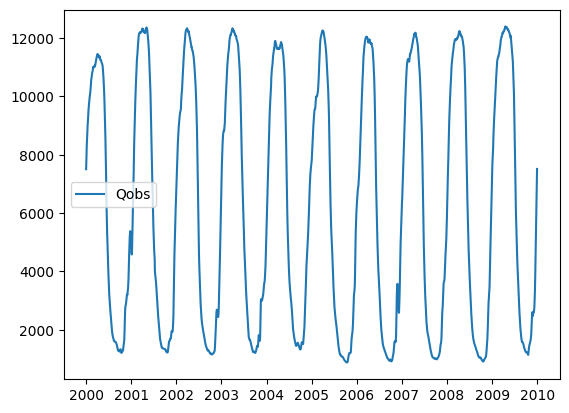

In [8]:
# Plot some years of data
%matplotlib inline
start_date = pd.to_datetime("2000-01-01", yearfirst=True)
end_date = pd.to_datetime("2009-12-31", yearfirst=True)
plt.plot(df.loc[start_date:end_date, 'Streamflow(m3/s)'], label='Qobs')
#plt.plot(val.loc[start_date:end_date, 'qsim_mc'], label='Qsim mc')
plt.legend()

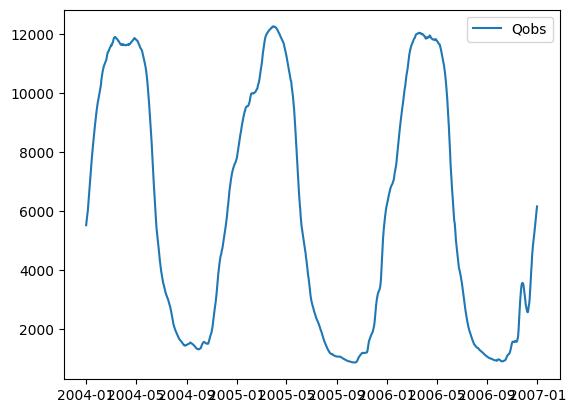

In [10]:
# Plot
start_date = pd.to_datetime("2004-01-01", yearfirst=True)
end_date = pd.to_datetime("2006-12-31", yearfirst=True)
plt.plot(df.loc[start_date:end_date, 'Streamflow(m3/s)'], label='Qobs')
#plt.plot(val.loc[start_date:end_date, 'qsim_mc'], label='Qsim mc')
plt.legend()

## Chuva-Vazão Purus

In [11]:
from datetime import datetime, timedelta

<Figure size 640x480 with 0 Axes>

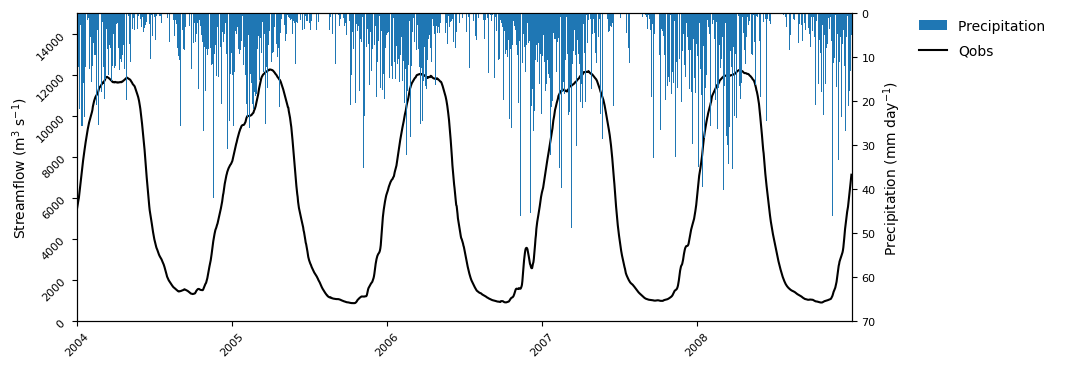

In [12]:
plt.gcf().autofmt_xdate()

fig, ax1 = plt.subplots(figsize=(10,4))

start_date = pd.to_datetime("2004-01-01", yearfirst=True)
end_date = pd.to_datetime("2008-12-31", yearfirst=True)

ax1.plot(df.loc[start_date:end_date, 'Streamflow(m3/s)'], label='Qobs', color = 'black')
#ax1.plot(val.loc[start_date:end_date, 'qsim_fit_Reola'], label='Qsim .fit()')
#ax1.plot(val.loc[start_date:end_date, 'qsim_mc'], label='Qsim mc')
ax1.set_ylim(0,15000)
ax1.margins(0.0)
ax1.tick_params(axis='both', labelsize=8,rotation=45) #increase font size for ticks
ax1.set_ylabel(r'Streamflow (m$^3$ s$^{-1}$)', fontsize=10) #y label

ax1.legend(bbox_to_anchor=(1.19, 0.92), borderaxespad=0.,frameon=False)

ax2 = ax1.twinx()
ax2.margins(0.0)
ax2.bar(df.loc[start_date:end_date].index,df.loc[start_date:end_date]['prec_PLUVIO_Thi(mm)'], width=1.8, label = 'Precipitation ')
#ax2.bar(val['2018-01-01':'2019-12-31'].index+timedelta(hours=6),val.loc[start_date:end_date,'P voru x10 (mm/day)'], width=1.8, label = 'Voru Precipitation ')
#ax2.bar(val['2018-01-01':'2019-12-31'].index+timedelta(hours=12),val.loc[start_date:end_date,'P smear (mm/day)'], width=1.8, label = 'Smear Precipitation ')

ax2.tick_params(axis='both', labelsize=8)
ax2.set_ylabel(r'Precipitation (mm day$^{-1}$)', fontsize=10) #y label
ax2.set_ylim(70,0)
ax2.legend(loc=0)

leg = plt.legend();

plt.legend(bbox_to_anchor=(1.08, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.savefig('_chuva_vazao_Purus.png', dpi = 300, bbox_inches='tight')
plt.show()

# Temperature data

In [13]:
df_cabra['t_mean'] = (df_cabra['tmax_ens(oC)']+df_cabra['tmin_ens(oC)'])/2
#df_cabra

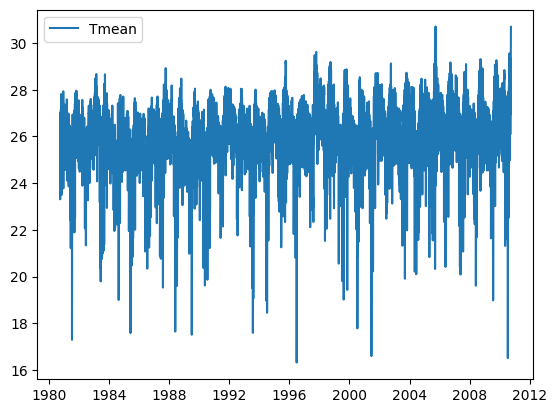

In [14]:
# Plot temperature
plt.plot(df_cabra['t_mean'], label='Tmean')
plt.legend()

<Figure size 640x480 with 0 Axes>

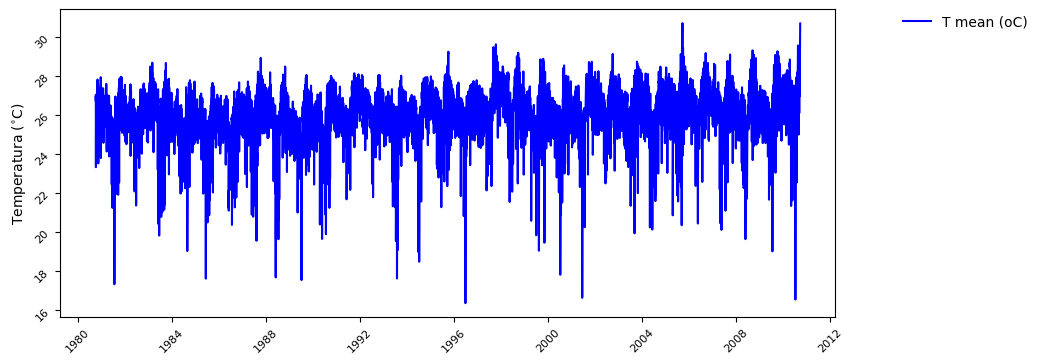

In [15]:
plt.gcf().autofmt_xdate()

fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(df_cabra['t_mean'], label='T mean (oC)', color = 'blue')
#ax1.set_ylim(0,15000)
#ax1.margins(0.0)
ax1.tick_params(axis='both', labelsize=8,rotation=45) #increase font size for ticks
ax1.set_ylabel(r'Temperatura ($^{\circ}$C)', fontsize=10) #y label

ax1.legend(bbox_to_anchor=(1.19, 0.92), borderaxespad=0.,frameon=False)
leg = plt.legend();

plt.legend(bbox_to_anchor=(1.08, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.savefig('_temperatura_Purus.png', dpi = 300, bbox_inches='tight')
plt.show()

# Separando componentes em dados de séries temporais com Python

Componentes de série temporal
Uma abstração útil para analisar uma série temporal é observar componentes sistemáticas e não sistemáticas.

* Sistemático: Componentes da série temporal que possuem consistência ou recorrência e podem ser descritos e modelados.
* Não Sistemático: Componentes da série temporal que não podem ser modelados por um modelo determinístico.

Uma série temporal consiste em três componentes sistemáticos: nível, tendência, sazonalidade e um componente não sistemático denominado ruído.

Esses componentes são definidos da seguinte forma:

* Nível: O valor médio da série.
* Tendência: O valor crescente ou decrescente na série.
* Sazonalidade: O ciclo repetitivo de um certo prazo na série.
* Ruído: A variação aleatória na série.

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot

### Decomposição aditiva

In [17]:
#series = df_cabra['t_mean']
#series = df_cabra['t_mean']
series = df['Streamflow(m3/s)']
result = seasonal_decompose(series, model='additive', period=365)

In [18]:
# print(result.trend)
# print(result.seasonal)
# print(result.resid)
# print(result.observed)

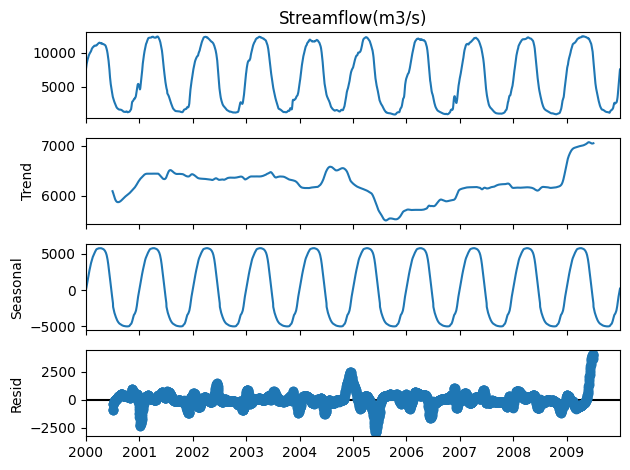

In [19]:
result.plot()
plt.savefig('_decoposicao_soma_vazao.png', dpi = 300, bbox_inches='tight')
plt.show()

### Decomposição multiplicativa

In [20]:
#series = df_cabra['t_mean']
#series = df_cabra['t_mean']
series = df['Streamflow(m3/s)']
result = seasonal_decompose(series, model='multiplicative', period=366)

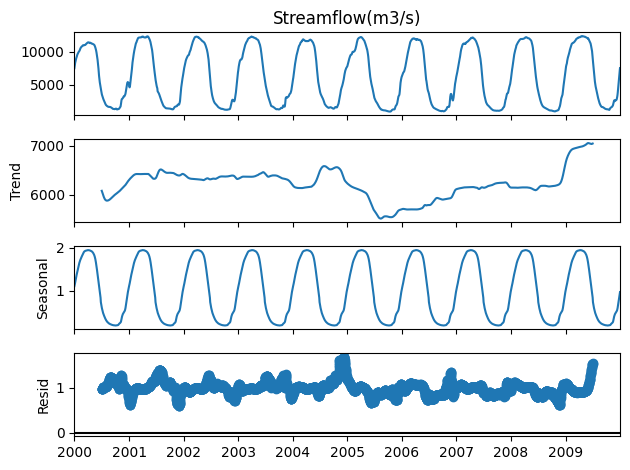

In [21]:
result.plot()
plt.savefig('_decoposicao_mult_vazao.png', dpi = 300, bbox_inches='tight')
plt.show()

<Axes: >

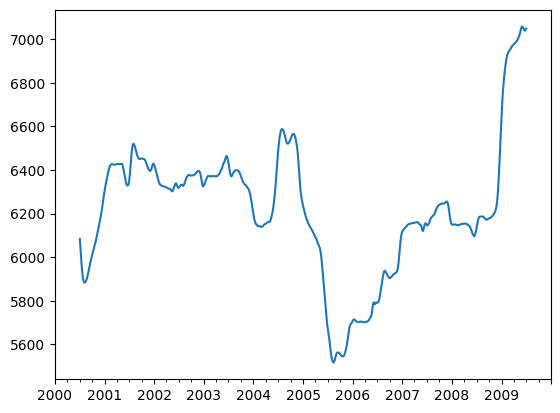

In [22]:
result.trend.plot()